Gen 0, Best = 8513.79
Gen 20, Best = 7240.49
Gen 40, Best = 7203.38
Gen 60, Best = 7203.38
Gen 80, Best = 7028.97
Gen 100, Best = 7028.97
Gen 120, Best = 7028.97
Gen 140, Best = 7028.97
Gen 160, Best = 6990.08
Gen 180, Best = 6990.08
Gen 200, Best = 6990.08
Gen 220, Best = 6990.08
Gen 240, Best = 6990.08
Gen 260, Best = 6990.08
Gen 280, Best = 6990.08
Gen 300, Best = 6990.08
Gen 320, Best = 6990.08
Gen 340, Best = 6990.08
Gen 360, Best = 6990.08
Gen 380, Best = 6990.08
Gen 400, Best = 6990.08
Gen 420, Best = 6990.08
Gen 440, Best = 6990.08
Gen 460, Best = 6990.08
Gen 480, Best = 6990.08

Best route: [45 43 34 33 35 38 39 36 37 47 23  4 14  5  3 24 11 27 26 25 46 12 13 51
 10 50 32 42  9  8  7 40 18 44 31 48  0 21 30 17  2 16 20 22 19 49 15 28
 29 41  6  1]
Best cost: 6990.0819801796615


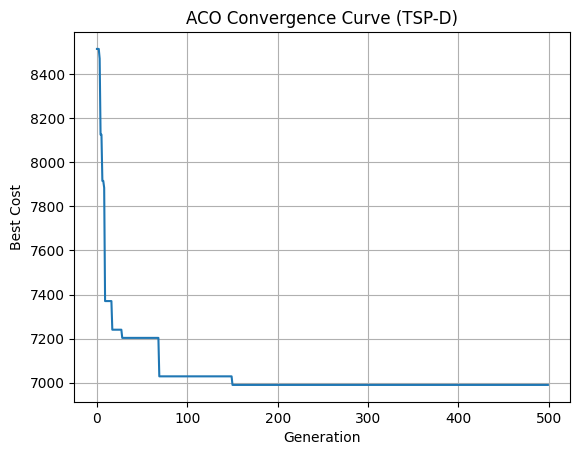

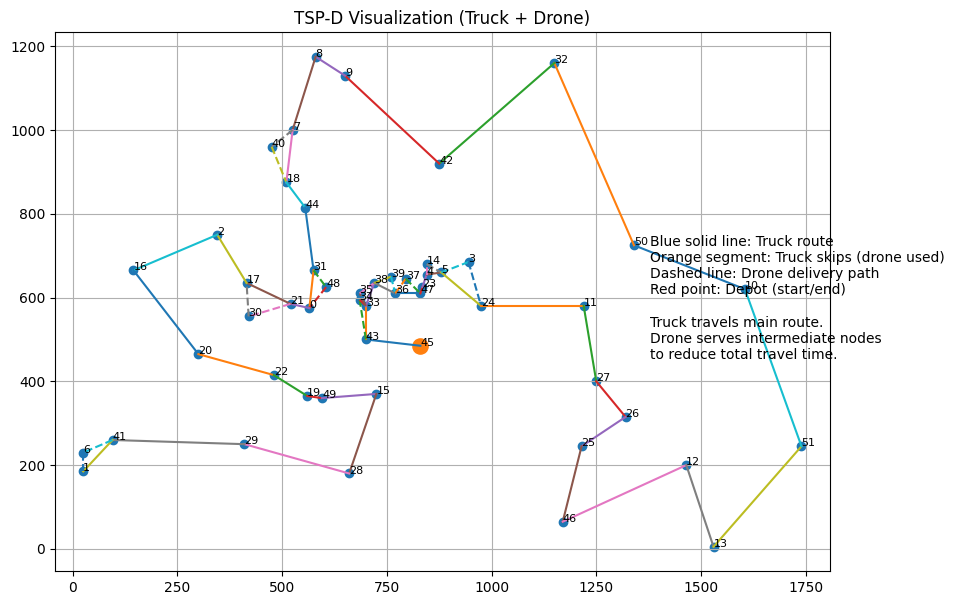


===== RUNNING 60 EXPERIMENTS =====
Run 1/60
Gen 0, Best = 8209.86
Gen 20, Best = 7176.14
Gen 40, Best = 6953.24
Gen 60, Best = 6953.24
Gen 80, Best = 6953.24
Gen 100, Best = 6953.24
Gen 120, Best = 6953.24
Gen 140, Best = 6953.24
Gen 160, Best = 6914.36
Gen 180, Best = 6914.36
Gen 200, Best = 6914.36
Gen 220, Best = 6914.36
Gen 240, Best = 6914.36
Gen 260, Best = 6914.36
Gen 280, Best = 6914.36
Gen 300, Best = 6914.36
Gen 320, Best = 6914.36
Gen 340, Best = 6914.36
Gen 360, Best = 6914.36
Gen 380, Best = 6914.36
Gen 400, Best = 6914.36
Gen 420, Best = 6914.36
Gen 440, Best = 6914.36
Gen 460, Best = 6914.36
Gen 480, Best = 6914.36
Run 2/60
Gen 0, Best = 7938.84
Gen 20, Best = 7021.42
Gen 40, Best = 7021.42
Gen 60, Best = 7021.42
Gen 80, Best = 7001.04
Gen 100, Best = 7001.04
Gen 120, Best = 7001.04
Gen 140, Best = 7000.75
Gen 160, Best = 6912.17
Gen 180, Best = 6912.17
Gen 200, Best = 6912.17
Gen 220, Best = 6912.17
Gen 240, Best = 6912.17
Gen 260, Best = 6912.17
Gen 280, Best = 6912.1

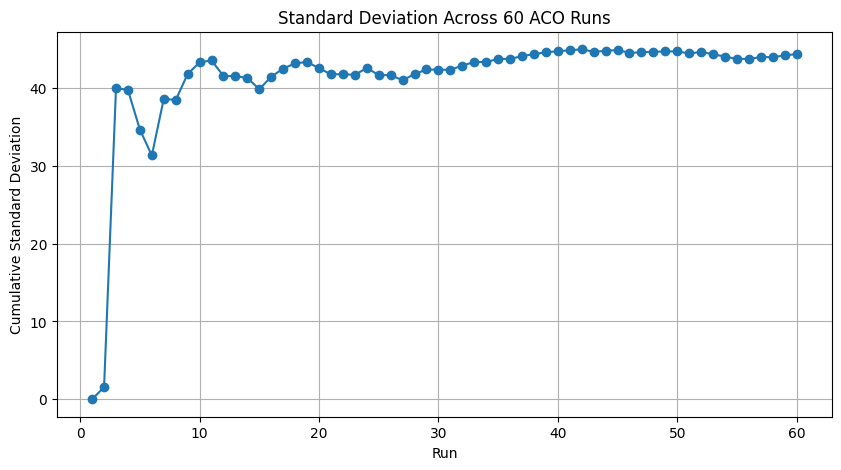

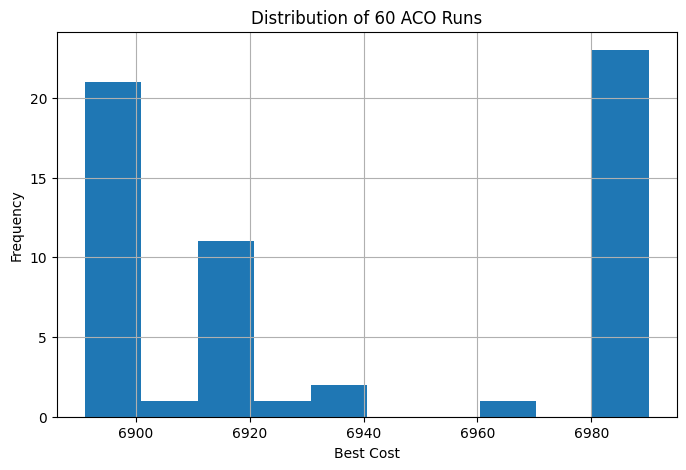

In [1]:
import numpy as np

# =========================
# READ TSPLIB
# =========================
def read_tsp(file_path):
    coords = []
    start = False

    with open(file_path, 'r') as f:
        for line in f:
            if "NODE_COORD_SECTION" in line:
                start = True
                continue
            if "EOF" in line:
                break
            if start:
                parts = line.strip().split()
                coords.append([float(parts[1]), float(parts[2])])

    return np.array(coords)


# =========================
# DIST MATRIX
# =========================
def compute_dist_matrix(coords):
    N = len(coords)
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            dist[i][j] = np.linalg.norm(coords[i] - coords[j])
    return dist


# =========================
# DECODE
# =========================
def decode(ind):
    return np.argsort(ind)


# =========================
# TSP-D COST
# =========================
DRONE_RANGE = 200
DRONE_SPEED = 1.5
TRUCK_SPEED = 1.0
WAIT_TIME = 5

def tspd_cost(route, dist):
    total = 0.0
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]

            saving = dist[a][b] + dist[b][c] - dist[a][c]

            if drone_dist <= DRONE_RANGE and saving > 5:
                total += max(truck_dist/TRUCK_SPEED,
                             drone_dist/DRONE_SPEED) + WAIT_TIME
                i += 2
                continue

        total += dist[a][b]
        i += 1

    return total


# =========================
# 2-OPT
# =========================
def two_opt(route, dist, max_iter=10):
    best = route.copy()
    best_cost = tspd_cost(best, dist)

    for _ in range(max_iter):
        improved = False
        for i in range(1, len(route)-2):
            for j in range(i+2, len(route)):
                new_route = best.copy()
                new_route[i:j] = best[j-1:i-1:-1]

                new_cost = tspd_cost(new_route, dist)

                if new_cost < best_cost:
                    best = new_route
                    best_cost = new_cost
                    improved = True

        if not improved:
            break

    return best


# =========================
# DE MAIN
# =========================
def ACO_tspd_fast(coords, ants=15, alpha=1, beta=5, rho=0.3, Q=100, GEN=500):
    dist = compute_dist_matrix(coords)
    N = len(coords)

    pheromone = np.ones((N, N), dtype=np.float64)
    heuristic = 1.0 / (dist + 1e-10)

    best_route = None
    best_cost = float("inf")
    history = []

    for g in range(GEN):
        all_routes = []
        all_costs = []

        for ant in range(ants):
            visited = np.zeros(N, dtype=bool)

            current = np.random.randint(N)
            route = [current]
            visited[current] = True

            # ===== BUILD ROUTE FAST =====
            for _ in range(N - 1):
                unvisited = np.where(~visited)[0]

                tau = pheromone[current, unvisited] ** alpha
                eta = heuristic[current, unvisited] ** beta
                probs = tau * eta
                probs /= probs.sum()

                next_city = np.random.choice(unvisited, p=probs)

                route.append(next_city)
                visited[next_city] = True
                current = next_city

            route = np.array(route)
            cost = tspd_cost(route, dist)

            all_routes.append(route)
            all_costs.append(cost)

            if cost < best_cost:
                best_cost = cost
                best_route = route.copy()

        # ===== LOCAL SEARCH CHỈ BEST =====
        if g > 100 and g % 50 == 0:
            improved = two_opt(best_route, dist, max_iter=3)
            improved_cost = tspd_cost(improved, dist)

            if improved_cost < best_cost:
                best_cost = improved_cost
                best_route = improved

        # ===== EVAPORATION =====
        pheromone *= (1 - rho)

        # ===== PHEROMONE UPDATE FAST =====
        for route, cost in zip(all_routes, all_costs):
            deposit = Q / cost
            a = route[:-1]
            b = route[1:]
            pheromone[a, b] += deposit
            pheromone[b, a] += deposit

        history.append(best_cost)

        if g % 20 == 0:
            print(f"Gen {g}, Best = {best_cost:.2f}")

    return best_route, best_cost, history

import matplotlib.pyplot as plt

def plot_convergence(history):
    plt.figure()
    plt.plot(history)
    plt.xlabel("Generation")
    plt.ylabel("Best Cost")
    plt.title("ACO Convergence Curve (TSP-D)")
    plt.grid()
    plt.show()

def visualize_tspd(coords, route, dist):
    import matplotlib.pyplot as plt

    DRONE_RANGE = 200
    DRONE_SPEED = 1.5
    TRUCK_SPEED = 1.0
    WAIT_TIME = 5

    plt.figure(figsize=(10, 7))

    route_coords = coords[route]

    # ===== VẼ NODE =====
    plt.scatter(coords[:, 0], coords[:, 1])

    # depot
    plt.scatter(route_coords[0, 0], route_coords[0, 1], s=120)

    # ===== DUYỆT ROUTE =====
    i = 0
    N = len(route)

    while i < N - 1:
        a = route[i]
        b = route[i+1]

        if i < N - 2:
            c = route[i+2]

            truck_dist = dist[a][c]
            drone_dist = dist[a][b] + dist[b][c]
            saving = dist[a][b] + dist[b][c] - dist[a][c]

            # ===== DÙNG DRONE =====
            if drone_dist <= DRONE_RANGE and saving > 5:

                # 🚚 truck đi A → C (cam)
                plt.plot([coords[a][0], coords[c][0]],
                         [coords[a][1], coords[c][1]])

                # 🚁 drone đi A → B
                plt.plot([coords[a][0], coords[b][0]],
                         [coords[a][1], coords[b][1]],
                         linestyle='dashed')

                # 🚁 drone đi B → C
                plt.plot([coords[b][0], coords[c][0]],
                         [coords[b][1], coords[c][1]],
                         linestyle='dashed')

                i += 2
                continue

        # ===== TRUCK BÌNH THƯỜNG =====
        plt.plot([coords[a][0], coords[b][0]],
                 [coords[a][1], coords[b][1]])

        i += 1

    # ===== LABEL NODE =====
    for idx in route:
        x, y = coords[idx]
        plt.text(x, y, str(idx), fontsize=8)

    # ===== LEGEND GIẢI THÍCH =====
    explanation = (
        "Blue solid line: Truck route\n"
        "Orange segment: Truck skips (drone used)\n"
        "Dashed line: Drone delivery path\n"
        "Red point: Depot (start/end)\n\n"
        "Truck travels main route.\n"
        "Drone serves intermediate nodes\n"
        "to reduce total travel time."
    )

    plt.gcf().text(0.72, 0.5, explanation, fontsize=10, va='center')

    # ===== FORMAT =====
    plt.title("TSP-D Visualization (Truck + Drone)")
    plt.axis('equal')
    plt.grid()

    plt.show()

def visualize_std_60_runs(coords, runs=60):
    """
    Chạy ACO nhiều lần và vẽ độ lệch chuẩn tích lũy
    """
    all_costs = []

    print("\n===== RUNNING 60 EXPERIMENTS =====")
    for run in range(runs):
        print(f"Run {run+1}/{runs}")

        _, best_cost, _ = ACO_tspd_fast(
            coords,
            ants=15,
            alpha=1,
            beta=5,
            rho=0.3,
            Q=100,
            GEN=500
        )

        all_costs.append(best_cost)

    all_costs = np.array(all_costs)

    # ===== THỐNG KÊ =====
    mean_cost = np.mean(all_costs)
    std_cost = np.std(all_costs, ddof=1)

    print("\n===== 60 RUNS STATISTICS =====")
    print(f"Mean = {mean_cost:.2f}")
    print(f"Std  = {std_cost:.2f}")
    print(f"Min  = {np.min(all_costs):.2f}")
    print(f"Max  = {np.max(all_costs):.2f}")

    # ===== STD TÍCH LŨY =====
    cumulative_std = []
    for i in range(1, len(all_costs) + 1):
        if i == 1:
            cumulative_std.append(0)
        else:
            cumulative_std.append(np.std(all_costs[:i], ddof=1))

    # ===== VISUAL STD =====
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, runs + 1), cumulative_std, marker='o')
    plt.xlabel("Run")
    plt.ylabel("Cumulative Standard Deviation")
    plt.title("Standard Deviation Across 60 ACO Runs")
    plt.grid(True)
    plt.show()

    # ===== HISTOGRAM =====
    plt.figure(figsize=(8, 5))
    plt.hist(all_costs, bins=10)
    plt.xlabel("Best Cost")
    plt.ylabel("Frequency")
    plt.title("Distribution of 60 ACO Runs")
    plt.grid(True)
    plt.show()

    return all_costs
# =========================
# MAIN
# =========================
if __name__ == "__main__":
    coords = read_tsp("berlin52.tsp")

    best_route, best_cost, history = ACO_tspd_fast(coords)

    print("\nBest route:", best_route)
    print("Best cost:", best_cost)

    dist = compute_dist_matrix(coords)
    plot_convergence(history)
    visualize_tspd(coords, best_route, dist)

    run_costs = visualize_std_60_runs(coords, runs=60)